# Basis for SVM model (needs to be adjusted to data and de-bugged)
Model basis below is based on work done for Programming Assignment #3. When the data set is done, we can try to run it and finish it. 

In [1]:
# importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import nltk
from nltk.stem import WordNetLemmatizer
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report as sk_classification_report
from sklearn.metrics import f1_score
from sklearn import datasets, linear_model, metrics
from sklearn import datasets, svm
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import FeatureUnion

In [2]:
def classification_report(y_true, y_pred, name):
    print(f"{name}")
    print(f"Macro F1: {f1_score(y_true, y_pred, average='macro') * 100:.2f}")
    print(sk_classification_report(y_true, y_pred, digits=3, zero_division=0))

In [3]:
# reading the file
train = pd.read_csv("data/combined/lyrics_train.csv")
eval_  = pd.read_csv("data/combined/lyrics_eval.csv")

X_train, y_train = train["text"], train["L1"]
X_eval,  y_eval  = eval_["text"], eval_["L1"]

print(f"Train: {len(X_train)} songs, classes: {y_train.value_counts().to_dict()}")
print(f"Eval:  {len(X_eval)} songs, classes: {y_eval.value_counts().to_dict()}")

Train: 165 songs, classes: {'french': 75, 'spanish': 59, 'italian': 31}
Eval:  20 songs, classes: {'italian': 11, 'french': 5, 'spanish': 4}


In [4]:
# adding a heading
train.head()

,artist_slug,artist_name,song_id,title,url,text,word_count,english_ratio,n_english_lines,n_total_lines,featured_artists,L1,genius_artist_id,lyrics,english_word_count
0,freeze_corleone,Freeze Corleone,6724242,Polémique,https://genius.com/Freeze-corleone-polemique-l...,"Yo Freeze, we're doing one ten through the cou...",NaN,0.344262,21,61,Central Cee,french,63888.0,S/o le Flem\nAllô ? Cee ? C'est comment ? T'as...,243.0
1,lomepal,Lomepal,4144358,Ma cousin,https://genius.com/Lomepal-ma-cousin-lyrics,"Um, like, don't come 'round here and try to fu...",NaN,0.191176,13,68,NaN,french,16138.0,Ahlan wa sahlan bikom 3ala track Lomepal 14 fi...,155.0
2,youssoupha,Youssoupha,62326,Dreamin’,https://genius.com/Youssoupha-dreamin-lyrics,"Miss me, miss me, you're the one who makes me ...",NaN,0.484848,32,66,Indila,french,1684.0,"Miss me, miss me, you're the one who makes me ...",243.0
3,youssoupha,Youssoupha,708823,Smile,https://genius.com/Youssoupha-smile-lyrics,"You make me, you make me, you make me smile\nY...",NaN,0.245283,13,53,Madame Monsieur,french,1684.0,Laisse tourner l'son\nOù sont les sourires au ...,142.0
4,doc_gynéco,Doc Gynéco,387622,Funky Maxime,https://genius.com/Doc-gyneco-funky-maxime-lyrics,I've got to know ya\nI want to know ya\nYou've...,NaN,0.476190,40,84,NaN,french,2298.0,"Encore des mots qui décapent, et du style dans...",223.0


In [5]:
X = X_train   # the full training data from Cell 3 (all 69 songs)
y = y_train

print(f"Total: {len(X)} songs, classes: {y.value_counts().to_dict()}")

Total: 165 songs, classes: {'french': 75, 'spanish': 59, 'italian': 31}


In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # fit vectorizer on training fold only (no leakage)
    vectorizer = FeatureUnion([
    ('word', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=1, sublinear_tf=True)),
    ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=1, sublinear_tf=True)),])
    
    X_tr_vec = vectorizer.fit_transform(X_tr)
    X_te_vec = vectorizer.transform(X_te)

    model = svm.LinearSVC(C=10.0, max_iter=5000, class_weight='balanced', random_state=42)
    model.fit(X_tr_vec, y_tr)
    preds = model.predict(X_te_vec)

    y_true_all.extend(y_te.tolist())
    y_pred_all.extend(preds.tolist())
    print(f"Fold {fold}: {len(y_te)} test songs, accuracy = {(preds == y_te).mean():.3f}")

Fold 1: 33 test songs, accuracy = 0.697
Fold 2: 33 test songs, accuracy = 0.636
Fold 3: 33 test songs, accuracy = 0.485
Fold 4: 33 test songs, accuracy = 0.697
Fold 5: 33 test songs, accuracy = 0.727


In [7]:
classification_report(y_true_all, y_pred_all, "LinearSVM (5-fold CV)")

LinearSVM (5-fold CV)
Macro F1: 52.95
              precision    recall  f1-score   support

      french      0.639     0.920     0.754        75
     italian      0.571     0.129     0.211        31
     spanish      0.680     0.576     0.624        59

    accuracy                          0.648       165
   macro avg      0.630     0.542     0.529       165
weighted avg      0.641     0.648     0.605       165



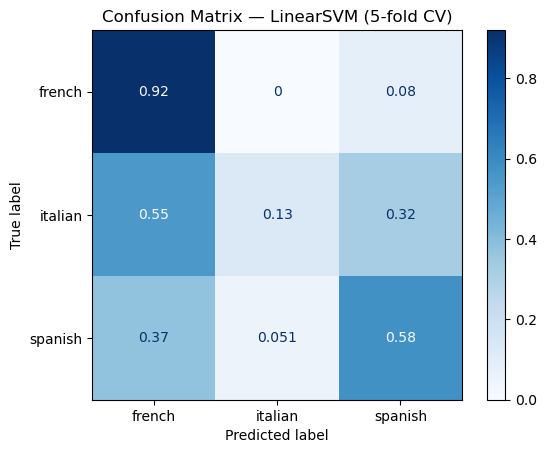

[[0.92 0.   0.08]
 [0.55 0.13 0.32]
 [0.37 0.05 0.58]]


In [8]:
np.set_printoptions(precision=2)

class_names = sorted(set(y_true_all))   # alphabetical: ['french', 'italian', 'spanish']

disp = ConfusionMatrixDisplay.from_predictions(
    y_true_all,
    y_pred_all,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize='true',
)
disp.ax_.set_title("Confusion Matrix — LinearSVM (5-fold CV)")
plt.show()

print(disp.confusion_matrix)

Fold 1: 33 test songs, accuracy = 0.576
Fold 2: 33 test songs, accuracy = 0.545
Fold 3: 33 test songs, accuracy = 0.424
Fold 4: 33 test songs, accuracy = 0.606
Fold 5: 33 test songs, accuracy = 0.485

RBF SVM (5-fold CV)
Macro F1: 35.04
              precision    recall  f1-score   support

      french      0.511     0.933     0.660        75
     italian      0.000     0.000     0.000        31
     spanish      0.607     0.288     0.391        59

    accuracy                          0.527       165
   macro avg      0.373     0.407     0.350       165
weighted avg      0.449     0.527     0.440       165



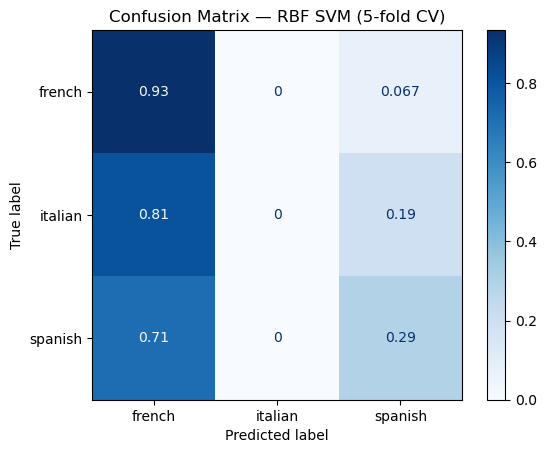

[[0.93 0.   0.07]
 [0.81 0.   0.19]
 [0.71 0.   0.29]]


In [9]:
# RBF SVM with 5-fold CV
y_true_rbf = []
y_pred_rbf = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    vectorizer = TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3, 5), min_df=1, sublinear_tf=True
    )
    X_tr_vec = vectorizer.fit_transform(X_tr)
    X_te_vec = vectorizer.transform(X_te)

    model = svm.SVC(C=1.0, kernel='rbf', class_weight='balanced', random_state=42)
    model.fit(X_tr_vec, y_tr)
    preds = model.predict(X_te_vec)

    y_true_rbf.extend(y_te.tolist())
    y_pred_rbf.extend(preds.tolist())
    print(f"Fold {fold}: {len(y_te)} test songs, accuracy = {(preds == y_te).mean():.3f}")

print()
classification_report(y_true_rbf, y_pred_rbf, "RBF SVM (5-fold CV)")

# confusion matrix
class_names = sorted(set(y_true_rbf))
disp = ConfusionMatrixDisplay.from_predictions(
    y_true_rbf, y_pred_rbf,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    normalize='true',
)
disp.ax_.set_title("Confusion Matrix — RBF SVM (5-fold CV)")
plt.show()
print(disp.confusion_matrix)